РК 1 Технологии разведочного анализа и обработки данных
Мосолова Е.С. ИБМ3-64Б 
14 Вариант

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv')
print(df.head())
print("\nПропуски в данных:")
print(df.isnull().sum())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Пропуски в данных:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [5]:
df_missing = df.copy()

# 10 пропусков в категориальном признаке 'University Rating'
np.random.seed(42)
missing_cat = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_cat, 'University Rating'] = np.nan

# 10 пропусков в количественном признаке 'CGPA'
missing_num = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_num, 'CGPA'] = np.nan

print("Пропуски после создания:")
print(df_missing[['University Rating', 'CGPA']].isnull().sum())

Пропуски после создания:
University Rating    10
CGPA                 10
dtype: int64


In [6]:
# Мода для категориального признака
mode_value = df_missing['University Rating'].mode()[0]
df_missing['University Rating'].fillna(mode_value, inplace=True)

print(f"Категориальный признак 'University Rating'")
print(f"Заполнен модой: {mode_value}")
print(f"Осталось пропусков: {df_missing['University Rating'].isnull().sum()}")

Категориальный признак 'University Rating'
Заполнен модой: 3.0
Осталось пропусков: 0


C:\Users\1\AppData\Local\Temp\ipykernel_9500\1486423045.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_missing['University Rating'].fillna(mode_value, inplace=True)


In [7]:
# Медиана для количественного признака
median_value = df_missing['CGPA'].median()
df_missing['CGPA'].fillna(median_value, inplace=True)

print(f"Количественный признак 'CGPA'")
print(f"Заполнен медианой: {median_value:.2f}")
print(f"Осталось пропусков: {df_missing['CGPA'].isnull().sum()}")

Количественный признак 'CGPA'
Заполнен медианой: 8.56
Осталось пропусков: 0


C:\Users\1\AppData\Local\Temp\ipykernel_9500\27280784.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_missing['CGPA'].fillna(median_value, inplace=True)


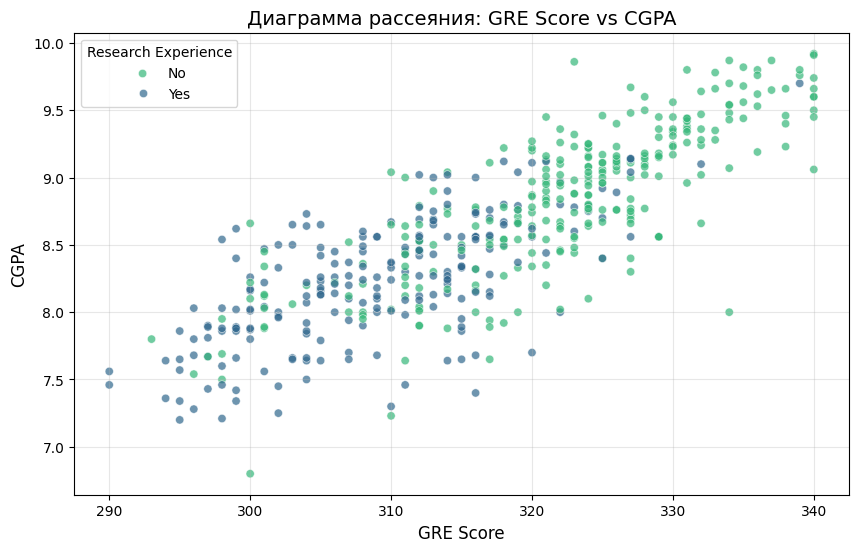

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_missing, x='GRE Score', y='CGPA', hue='Research', alpha=0.7, palette='viridis')
plt.title('Диаграмма рассеяния: GRE Score vs CGPA', fontsize=14)
plt.xlabel('GRE Score', fontsize=12)
plt.ylabel('CGPA', fontsize=12)
plt.legend(title='Research Experience', labels=['No', 'Yes'])
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
print("Признаки для построения моделей ML:\n")
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']
for i, f in enumerate(features, 1):
    print(f"{i}. {f}")

print("\nНе используется: 'Serial No.' (просто индекс)")

print("\nПричины выбора:")
print("- Все признаки содержат информацию, влияющую на поступление")
print("- GRE и CGPA — объективные академические метрики")
print("- Research — бинарный признак, сильно коррелирует с успехом")
print("- SOP и LOR — субъективные, но числовые и полезные")
print("- University Rating — отражает престиж вуза")

Признаки для построения моделей ML:

1. GRE Score
2. TOEFL Score
3. University Rating
4. SOP
5. LOR
6. CGPA
7. Research

Не используется: 'Serial No.' (просто индекс)

Причины выбора:
- Все признаки содержат информацию, влияющую на поступление
- GRE и CGPA — объективные академические метрики
- Research — бинарный признак, сильно коррелирует с успехом
- SOP и LOR — субъективные, но числовые и полезные
- University Rating — отражает престиж вуза


Вопрос 1: Какие способы обработки пропусков использовали?
text
- Для категориального признака 'University Rating': заполнение модой (наиболее часто встречающимся значением)
- Для количественного признака 'CGPA': заполнение медианой (устойчива к выбросам)

Вопрос 2: Какие признаки будете использовать для ML и почему?
text
Использую 7 признаков: GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, Research

Почему:
1. GRE Score + CGPA — ключевые академические показатели
2. TOEFL Score — важен для иностранных студентов
3. Research — опыт исследований повышает шансы
4. SOP + LOR — качество документов влияет на решение
5. University Rating — престиж вуза имеет значение

Не использую только 'Serial No.' — это бесполезный идентификатор